2026-08-31 21:23:33.685 | INFO     | __main__:node_output:65 - node_output is running...........


{'final_output': '关于莲花主题的七言绝句：《咏莲》\n玉立亭亭水云间，清姿雅韵绝尘寰。\n中通外直修真性，不蔓不枝最等闲。\n\n赏析：这首作品以莲花为题，通过“玉立亭亭”、“清姿雅韵”等生动描绘，展现其超脱尘世的姿态。后两句化用周敦颐《爱莲说》意蕴，以“中通外直”、“不蔓不枝”赞其内在品性，尾句“最等闲”更显其淡泊从容之境，全诗托物言志，将莲花清雅高洁的意象与君子品格完美交融。, \n笑话： 这个问题让我灵光一闪，给您讲一个关于“莲”的笑话：\n\n---\n\n**《莲的凡尔赛》**\n\n池塘里，莲花对荷叶抱怨：\n“唉，我真羡慕你们荷叶，每天躺着晒大阳，我就惨了——天天得‘出淤泥而不染’，搞得全人类都知道我是从泥里爬出来的。这‘白莲花’人设，真是太累了。”\n\n荷叶翻了个白眼：\n“那你倒是别长藕啊！每次被人挖出来，搞得我们全家都像‘泥腿子’出身。”\n\n莲花不服气：\n“起码我还能上‘朋友圈’装个岁月静好。你看看你，站了一辈子，最后还不是被拿去包粽子？”\n\n这时，池底的藕实在听不下去了，幽幽地冒出一句：\n“你们俩别吵了，我才是‘藕断丝连’的幕后总导演。没有我编的剧本，你们哪来的戏？”\n\n---\n\n**哲理与笑点**：  \n这个笑话讽刺了“完美人设”（莲花）的刻意、“躺平主义”（荷叶）的优越感，以及真正干实事的（藕）被忽视的委屈。笑完一想：原来“出淤泥而不染”不仅是一句赞美，还是一种被架上去的“道德绑架”啊。 \n '}


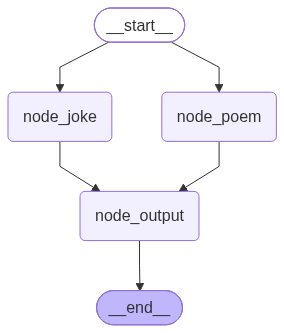

In [2]:
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.checkpoint.memory import InMemorySaver
import time
from operator import add
from langchain_core.messages import ToolMessage, SystemMessage
from random import randint

from langchain_core.runnables import RunnableConfig
from langgraph.cache.memory import InMemoryCache
from langgraph.errors import GraphRecursionError
from langgraph.graph import MessagesState

from multiprocessing import resource_tracker

from langgraph.graph import StateGraph, START, END, MessagesState, MessageGraph
from typing import TypedDict, Literal, Sequence, Annotated
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
from langchain.tools import tool
from langgraph.managed.is_last_step import RemainingSteps
from loguru import logger
from langgraph.types import Send, Command, CachePolicy
from langchain.messages import HumanMessage, AIMessage, SystemMessage
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)


class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    final_output: str

class InputState(TypedDict):
    topic: str

class OutputState(TypedDict):
    final_output: str

def node_poem(state: InputState) -> OverAllState:
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于{topic}的七言绝句")]).content
    return {
        "poem": poem,
    }

def node_joke(state: InputState) -> OverAllState:
    topic = state["topic"]
    joke = model.invoke([HumanMessage(f"写一首关于{topic}的笑话")]).content
    return {
        "joke": joke,
    }

def node_output(state: OverAllState) -> OverAllState:
    logger.info("node_output is running...........")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于{topic}主题的七言绝句：{poem}, \n笑话： {joke} \n "
    return {
        "final_output": final_output,
    }

builder = StateGraph(state_schema=OverAllState,input_schema=InputState,output_schema=OutputState)
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_output", node_output)
builder.add_edge(START, "node_poem")
builder.add_edge(START, "node_joke")
builder.add_edge("node_poem", "node_output")
builder.add_edge("node_joke", "node_output")
builder.add_edge("node_output", END)

checkpointer = InMemorySaver()
config = {
    "configurable": {
        "thread_id": 123
    }
}

graph = builder.compile(checkpointer=checkpointer)
res = graph.invoke({"topic": "莲花"}, config=config)
print(res)
display(graph)

In [4]:
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)


[StateSnapshot(values={'topic': '莲花', 'poem': '《咏莲》\n玉立亭亭水云间，清姿雅韵绝尘寰。\n中通外直修真性，不蔓不枝最等闲。\n\n赏析：这首作品以莲花为题，通过“玉立亭亭”、“清姿雅韵”等生动描绘，展现其超脱尘世的姿态。后两句化用周敦颐《爱莲说》意蕴，以“中通外直”、“不蔓不枝”赞其内在品性，尾句“最等闲”更显其淡泊从容之境，全诗托物言志，将莲花清雅高洁的意象与君子品格完美交融。', 'joke': '这个问题让我灵光一闪，给您讲一个关于“莲”的笑话：\n\n---\n\n**《莲的凡尔赛》**\n\n池塘里，莲花对荷叶抱怨：\n“唉，我真羡慕你们荷叶，每天躺着晒大阳，我就惨了——天天得‘出淤泥而不染’，搞得全人类都知道我是从泥里爬出来的。这‘白莲花’人设，真是太累了。”\n\n荷叶翻了个白眼：\n“那你倒是别长藕啊！每次被人挖出来，搞得我们全家都像‘泥腿子’出身。”\n\n莲花不服气：\n“起码我还能上‘朋友圈’装个岁月静好。你看看你，站了一辈子，最后还不是被拿去包粽子？”\n\n这时，池底的藕实在听不下去了，幽幽地冒出一句：\n“你们俩别吵了，我才是‘藕断丝连’的幕后总导演。没有我编的剧本，你们哪来的戏？”\n\n---\n\n**哲理与笑点**：  \n这个笑话讽刺了“完美人设”（莲花）的刻意、“躺平主义”（荷叶）的优越感，以及真正干实事的（藕）被忽视的委屈。笑完一想：原来“出淤泥而不染”不仅是一句赞美，还是一种被架上去的“道德绑架”啊。', 'final_output': '关于莲花主题的七言绝句：《咏莲》\n玉立亭亭水云间，清姿雅韵绝尘寰。\n中通外直修真性，不蔓不枝最等闲。\n\n赏析：这首作品以莲花为题，通过“玉立亭亭”、“清姿雅韵”等生动描绘，展现其超脱尘世的姿态。后两句化用周敦颐《爱莲说》意蕴，以“中通外直”、“不蔓不枝”赞其内在品性，尾句“最等闲”更显其淡泊从容之境，全诗托物言志，将莲花清雅高洁的意象与君子品格完美交融。, \n笑话： 这个问题让我灵光一闪，给您讲一个关于“莲”的笑话：\n\n---\n\n**《莲的凡尔赛》**\n\n池塘里，莲花对荷叶抱怨：\n“唉，我真羡慕你们荷叶，每天躺着晒大阳，我就惨了——天天得‘出淤泥而不染’，搞得全人类都知道我是从泥里爬出来的。这‘白莲花’人设，真是

AttributeError: 'list' object has no attribute 'prety_print'